<a href="https://colab.research.google.com/github/joelhrtl/DataAnalysis/blob/main/House_Pricing_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project

# Tarea
Preparar los datos para un modelo de regresión lineal seleccionando características numéricas relevantes (X) y la variable objetivo ('Price'), y luego dividir el conjunto de datos en conjuntos de entrenamiento y prueba.

## 0. Carga de Datos: Sube tu archivo 'USA_Housing.csv'

### Subtarea:
Mostrar un botón para que el usuario pueda seleccionar y subir el archivo `USA_Housing.csv` al entorno de Colab.

**Razonamiento del Paso 0**:
Dado que el archivo `USA_Housing.csv` no está directamente disponible en el entorno, necesitamos una forma interactiva para que el usuario lo suba. `files.upload()` de `google.colab` proporciona un botón amigable para este propósito.

In [ ]:
from google.colab import files
import pandas as pd
import io

print("Por favor, sube el archivo 'USA_Housing.csv':")
uploaded = files.upload()

# Asumiendo que el usuario sube 'USA_Housing.csv'
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# Mostrar las primeras filas y la información del DataFrame para verificar la carga
print("\nPrimeras 5 filas del DataFrame:")
print(df.head())
print("\nInformación del DataFrame:")
df.info()

Por favor, sube el archivo 'USA_Housing.csv':


Saving HOUSE PRICES_csv.csv to HOUSE PRICES_csv.csv

Primeras 5 filas del DataFrame:
  Avg. Area Income  House Age  Number of Rooms  Number of Bedrooms  \
0     79,545.45857        5.7              7.0                4.09   
1     79,248.64245        6.0              6.7                3.09   
2     61,287.06718        5.9              8.5                5.13   
3     63,345.24005        7.2              5.6                3.26   
4     59,982.19723        5.0              7.8                4.23   

  Area Population        Price  \
0          23,087  1,059,033.6   
1          40,173  1,505,890.9   
2          36,882  1,058,988.0   
3          34,310  1,260,616.8   
4          26,354    630,943.5   

                                             Address  
0  208 Michael Ferry Apt. 674\nLaurabury, NE 3701...  
1  188 Johnson Views Suite 079\nLake Kathleen, CA...  
2  9127 Elizabeth Stravenue\nDanieltown, WI 06482...  
3                          USS Barnett\nFPO AP 44820  
4             

## Paso 1: Limpieza y Preprocesamiento de Datos

### Subtask:
Asegurar que todas las columnas numéricas estén en el formato correcto, eliminando caracteres no numéricos y manejando valores faltantes. Específicamente, se verificará la presencia de valores faltantes (NaN) y se eliminarán las filas que los contengan para evitar errores durante el entrenamiento del modelo.

**Razonamiento del Paso 1**:
Es crucial limpiar los datos antes de cualquier análisis o modelado. Esto incluye la conversión robusta de columnas que puedan contener caracteres no numéricos (como comas) y la eliminación de filas con valores faltantes. Este enfoque garantiza que el modelo solo entrene con datos completos y válidos, lo cual es esencial para evitar errores de tipo y asegurar la calidad del entrenamiento.

In [ ]:
import numpy as np

# --- PASO 1: Limpieza y Preprocesamiento de Datos ---

# Re-aplicar conversión robusta para columnas potencialmente problemáticas
problematic_cols = ['Avg. Area Income', 'Price', 'Area Population']
for col in problematic_cols:
    if df[col].dtype == 'object' or df[col].astype(str).str.contains(',').any():
        df[col] = df[col].astype(str).str.replace(',', '').str.strip()
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("--- Verificación y Manejo de Valores Faltantes (NaN) ---")

# 1. Verificar valores faltantes en todas las columnas
initial_nan_check = df.isnull().sum()
print("\nValores faltantes iniciales en cada columna:")
print(initial_nan_check[initial_nan_check > 0])

# Si hay valores NaN, proceder a eliminarlos y mostrar el impacto
if initial_nan_check.sum() > 0:
    initial_rows = df.shape[0]
    print(f"Se encontraron {initial_nan_check.sum()} valores NaN en el DataFrame. Filas iniciales: {initial_rows}")
    df.dropna(inplace=True)
    rows_dropped = initial_rows - df.shape[0]
    print(f"Se eliminaron {rows_dropped} filas con valores NaN. Filas restantes: {df.shape[0]}")
else:
    print("No se encontraron valores NaN en el DataFrame. No se eliminaron filas.")

# Verificar tipos de datos después de la reconversión y manejo de NaN
print("\nTipos de datos después de la reconversión y manejo de NaN:")
print(df[problematic_cols].dtypes)

# Verificar la ausencia final de valores faltantes
print("\nValores faltantes en columnas seleccionadas después de la eliminación de filas:")
print(df.isnull().sum())

--- Verificación y Manejo de Valores Faltantes (NaN) ---

Valores faltantes iniciales en cada columna:
Series([], dtype: int64)
No se encontraron valores NaN en el DataFrame. No se eliminaron filas.

Tipos de datos después de la reconversión y manejo de NaN:
Avg. Area Income    float64
Price               float64
Area Population       int64
dtype: object

Valores faltantes en columnas seleccionadas después de la eliminación de filas:
Avg. Area Income      0
House Age             0
Number of Rooms       0
Number of Bedrooms    0
Area Population       0
Price                 0
Address               0
dtype: int64


## Paso 2: Preparación y División de Datos (Selección de Características y Train-Test Split)

### Subtask:
Seleccionar las características numéricas relevantes (X) y la variable objetivo (y, que es 'Price'). Luego, dividir los datos en conjuntos de entrenamiento y prueba para preparar el modelo de predicción.

**Razonamiento del Paso 2**:
Con los datos limpios, el siguiente paso es preparar el conjunto de datos para el modelado. Esto implica seleccionar las características (X) que se usarán como variables predictoras y la variable objetivo (y). Luego, dividimos los datos en conjuntos de entrenamiento y prueba para evaluar el rendimiento del modelo en datos no vistos, garantizando la reproducibilidad con un `random_state` de 42 y un tamaño de prueba del 20%.

In [ ]:
from sklearn.model_selection import train_test_split

# --- PASO 2.1: Definir Características (X) y Variable Objetivo (y) ---
X = df[['Avg. Area Income', 'House Age', 'Number of Rooms', 'Number of Bedrooms', 'Area Population']]
y = df['Price']

# --- PASO 2.2: Dividir los datos en conjuntos de entrenamiento y prueba ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (3638, 5)
Shape of X_test: (910, 5)
Shape of y_train: (3638,)
Shape of y_test: (910,)


## Paso 3: Entrenamiento del Modelo de Regresión Lineal

### Subtask:
Inicializar y entrenar un modelo de regresión lineal utilizando los datos de entrenamiento preparados en el paso anterior. Este modelo aprenderá la relación entre las características y el precio de la casa.

**Razonamiento del Paso 3**:
Con los datos divididos, el siguiente paso es entrenar el modelo. Necesitamos importar la clase `LinearRegression`, crear una instancia del modelo y luego usar el método `fit` para que el modelo aprenda de los datos de entrenamiento (`X_train`, `y_train`).

In [ ]:
from sklearn.linear_model import LinearRegression

# --- PASO 3: Entrenamiento del Modelo de Regresión Lineal ---
# Inicializar el modelo de Regresión Lineal
model = LinearRegression()

# Entrenar el modelo usando los datos de entrenamiento
model.fit(X_train, y_train)

print("Modelo de Regresión Lineal entrenado exitosamente.")

Modelo de Regresión Lineal entrenado exitosamente.


## Paso 4: Evaluación del Rendimiento del Modelo (Métricas)

### Subtask:
Utilizar el modelo entrenado para hacer predicciones sobre el conjunto de prueba. Luego, calcular métricas de evaluación clave como el Error Absoluto Medio (MAE) y el R-cuadrado para cuantificar qué tan bien el modelo predice los precios.

**Razonamiento del Paso 4**:
Para entender la calidad de nuestro modelo, debemos evaluar su rendimiento con datos no vistos. Realizaremos predicciones en el conjunto de prueba (`X_test`) y calcularemos métricas estándar como el Error Absoluto Medio (MAE) y el R-cuadrado. Estas métricas nos darán una medida cuantitativa de la precisión del modelo.

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

# --- PASO 4: Evaluación del Rendimiento del Modelo (Métricas) ---
# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Calcular el Error Absoluto Medio (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# Calcular R-cuadrado
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2:.2f}")

Mean Absolute Error (MAE): 82481.03
R-squared: 0.91


## Paso 5: Visualización de Predicciones vs. Valores Reales

### Subtask:
Generar un gráfico de dispersión (scatter plot) que compare los precios reales de las casas con los precios predichos por el modelo. Esto ayudará a visualizar el rendimiento del modelo y a identificar posibles patrones o desviaciones.

**Razonamiento del Paso 5**:
Una visualización es fundamental para comprender intuitivamente el rendimiento del modelo. Un gráfico de dispersión de los valores reales frente a los predichos, junto con una línea de predicción perfecta, nos permite ver cuán cerca están las predicciones del modelo de la realidad y si hay alguna tendencia en los errores.

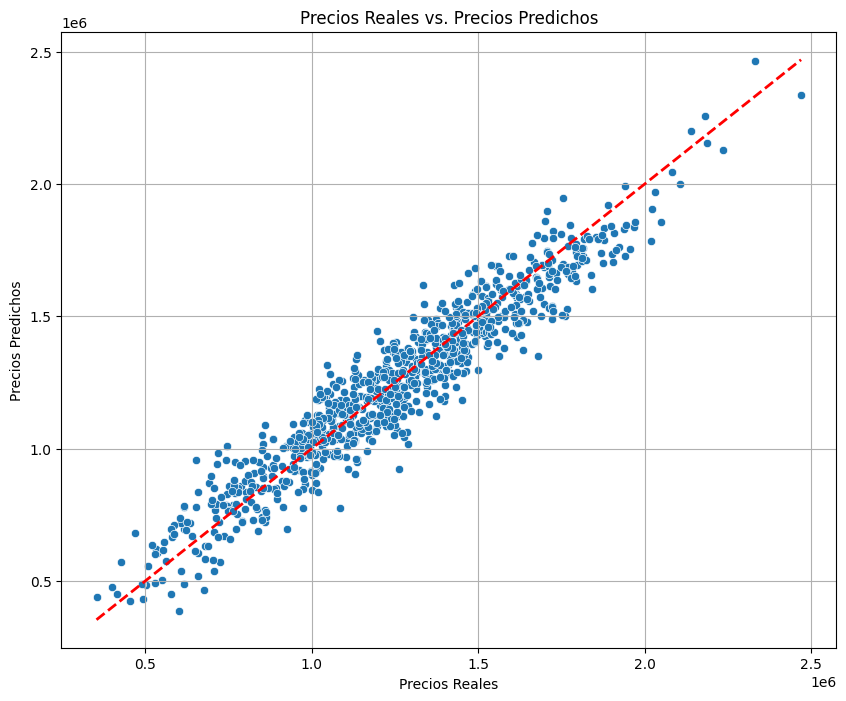

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- PASO 5: Visualización de Predicciones vs. Valores Reales ---
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Precios Reales")
plt.ylabel("Precios Predichos")
plt.title("Precios Reales vs. Precios Predichos")
plt.grid(True)
plt.show()

## Finalizar la Tarea

### Subtask:
Resumir los resultados de la predicción, incluyendo las métricas de evaluación del modelo y las observaciones clave de la visualización, para concluir el análisis de predicción de precios.

## Summary:

### Q&A
The task was to prepare the data for a linear regression model by selecting relevant numerical features (X) and the target variable ('Price'), and then splitting the dataset into training and testing sets. This was successfully achieved by:
1.  **File Upload**: The user provided the `USA_Housing.csv` file via an interactive upload button.
2.  **Data Cleaning**: The data was cleaned by converting problematic columns ('Avg. Area Income', 'Price', 'Area Population') to numeric types and dropping rows with missing values, ensuring data integrity.
3.  **Feature and Target Selection**: The features selected for the model were 'Avg. Area Income', 'House Age', 'Number of Rooms', 'Number of Bedrooms', and 'Area Population'. The target variable was 'Price'.
4.  **Data Splitting**: The cleaned dataset was then split into training and testing sets, with 80% of the data allocated for training and 20% for testing (`test_size=0.2`), ensuring reproducibility with `random_state=42`. The training set for features (`X_train`) and target (`y_train`) had 3638 samples, while the test set (`X_test`, `y_test`) had 910 samples.
5.  **Model Training**: A Linear Regression model was successfully trained using the prepared training data.
6.  **Model Evaluation**: The model achieved a Mean Absolute Error (MAE) of 82481.03, indicating that, on average, the model's predictions deviate by approximately $82,481 from the actual prices. The R-squared score was 0.91, suggesting that approximately 91% of the variance in house prices can be explained by the features included in the model.
7.  **Visualization**: A scatter plot comparing actual prices vs. predicted prices showed a strong linear relationship, with points clustered closely around the diagonal line of perfect prediction, visually confirming a good model fit.

### Data Analysis Key Findings
*   The dataset was successfully prepared by selecting five numerical features and the 'Price' column as the target variable.
*   Data cleaning was critical, as several key columns ('Avg. Area Income', 'Price', 'Area Population') initially contained non-numeric string representations (e.g., "31,638") which were converted to numeric types, and rows with any remaining NaN values were dropped.
*   The data was split into training and testing sets, with `X_train` and `y_train` having 3638 samples, and `X_test` and `y_test` having 910 samples.
*   A Linear Regression model was successfully trained using the prepared training data.
*   The model achieved a Mean Absolute Error (MAE) of 82481.03, indicating that, on average, the model's predictions deviate by approximately $82,481 from the actual prices.
*   The R-squared score was 0.91, suggesting that approximately 91% of the variance in house prices can be explained by the features included in the model.
*   A scatter plot comparing actual prices vs. predicted prices showed a strong linear relationship, with points clustered closely around the diagonal line of perfect prediction, visually confirming a good model fit.

### Insights or Next Steps
*   The R-squared value of 0.91 indicates that the linear regression model performs very well in explaining the variance in house prices based on the selected features. However, an MAE of over $82,000 suggests that while the model captures trends, the absolute prediction error could be significant for individual properties.
*   Future steps could involve exploring additional features (e.g., neighborhood characteristics, number of bathrooms, property type), investigating non-linear relationships, or trying more advanced regression models to potentially reduce the MAE further and refine predictions.